In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../dataset/Sample - Superstore.csv', encoding='latin1')

In [2]:
df.head()



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.shape


(9994, 21)

In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [5]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [6]:
df.dropna(inplace=True)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [10]:
df['Year']=df['Order Date'].dt.year
df['Month']=df['Order Date'].dt.month
df['Month_Name']=df['Order Date'].dt.month_name()
df['Day']=df['Order Date'].dt.day




In [11]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month_Name,Day
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,8
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,8
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,12
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,11
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,11


In [12]:
total_sales=df['Sales'].sum()
print("Total Sales",total_sales)

Total Sales 2297200.8603000003


In [13]:
total_profit = df['Profit'].sum()
print("Total profit", total_profit)

Total profit 286397.0217


In [14]:
category_sales = df.groupby('Category')['Sales'].sum()
print(category_sales)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


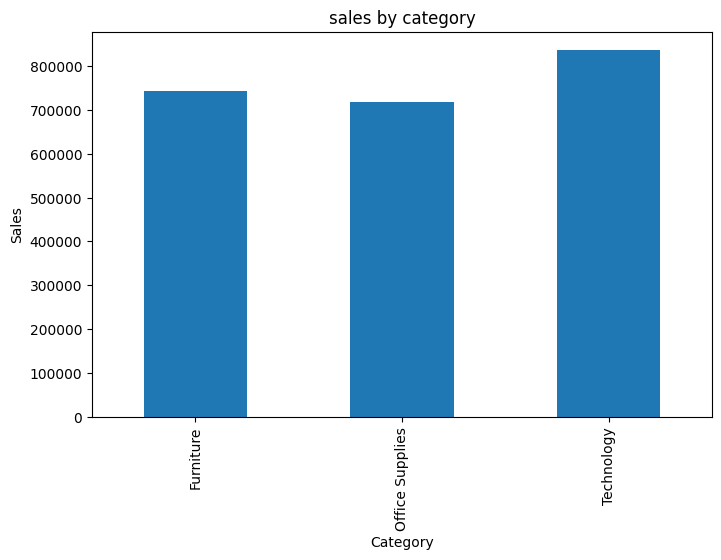

In [15]:
category_sales.plot(kind='bar',figsize=(8,5))
plt.title('sales by category')
plt.xlabel('Category')
plt.ylabel('Sales')

plt.show()


In [16]:
monthly_sales = df.groupby('Month_Name')['Sales'].sum()

print(monthly_sales)

Month_Name
April        137762.1286
August       159044.0630
December     325293.5035
February      59751.2514
January       94924.8356
July         147238.0970
June         152718.6793
March        205005.4888
May          155028.8117
November     352461.0710
October      200322.9847
September    307649.9457
Name: Sales, dtype: float64


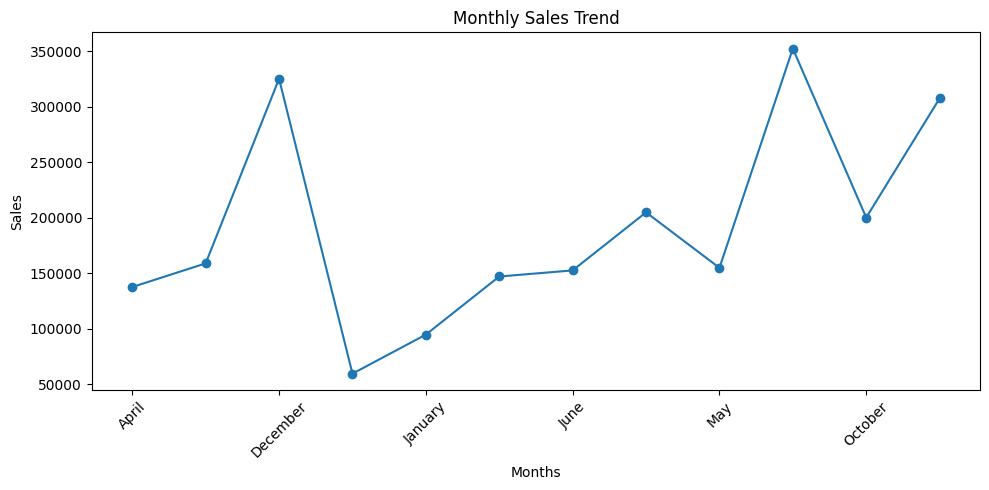

In [45]:
monthly_sales.plot(kind='line', marker='o', figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.xlabel('Months')
plt.ylabel('Sales')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [18]:
category_profit=df.groupby('Category')['Sales'].sum()
print(category_profit)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


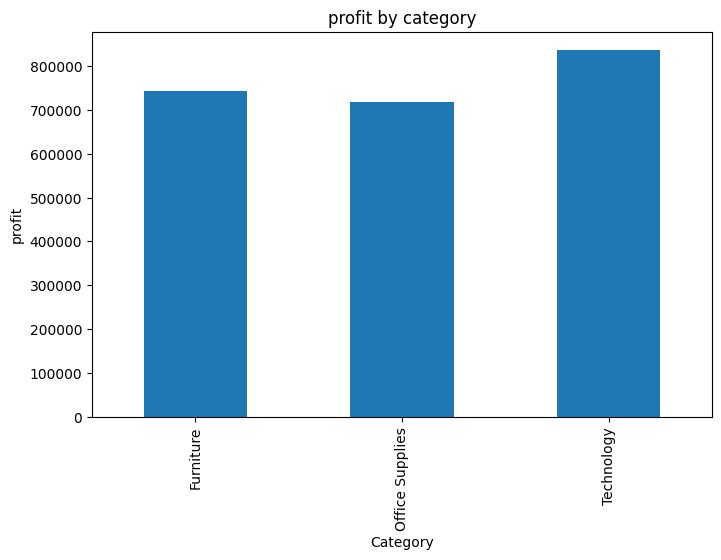

In [19]:
category_profit.plot(kind='bar',figsize=(8,5))
plt.title('profit by category')
plt.xlabel('Category')
plt.ylabel('profit')
plt.show()

In [20]:
region_sales=df.groupby('Region')['Sales'].sum()
print(region_sales)

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


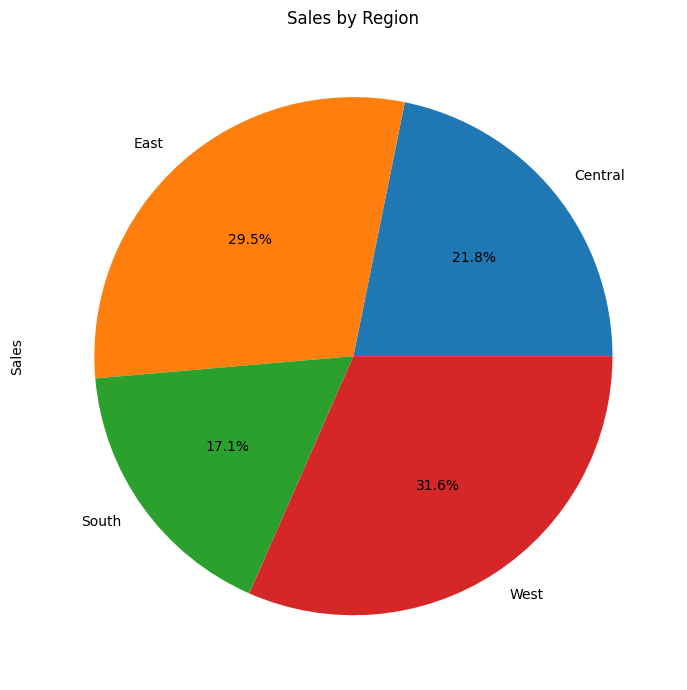

In [21]:
region_sales.plot(kind='pie', autopct='%1.1f%%', figsize=(7,7))

plt.title('Sales by Region')

plt.tight_layout()

plt.show()

In [22]:
top_products=df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


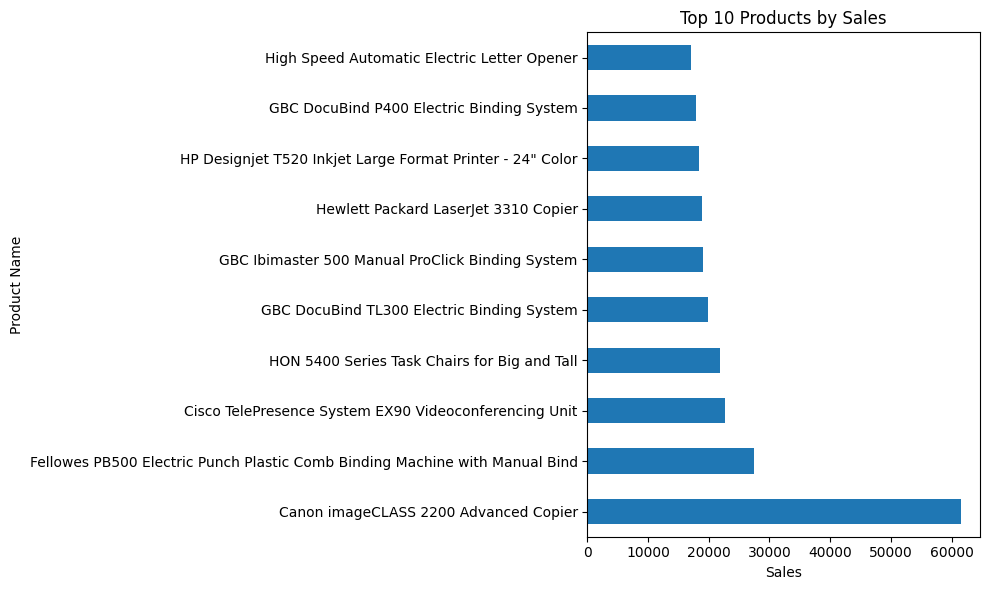

In [23]:
top_products.plot(kind='barh', figsize=(10,6))

plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product Name')

plt.tight_layout()

plt.show()

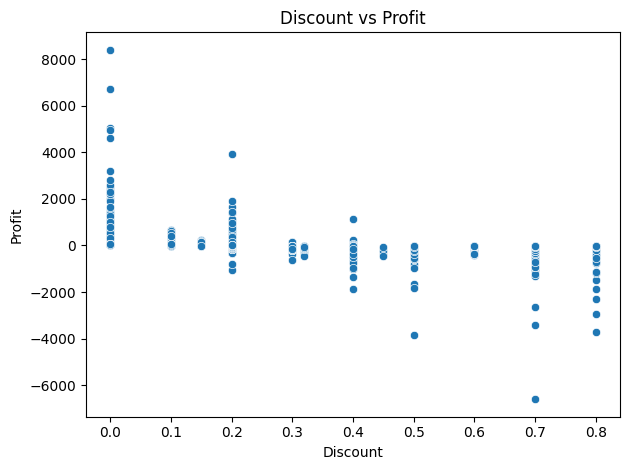

In [24]:
plt.Figure(figsize=(8,5))
sns.scatterplot(x='Discount',y='Profit',data=df)
plt.title('Discount vs Profit')
plt.tight_layout()
plt.show()


In [25]:
segment_sales = df.groupby('Segment')['Sales'].sum()

print(segment_sales)

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64


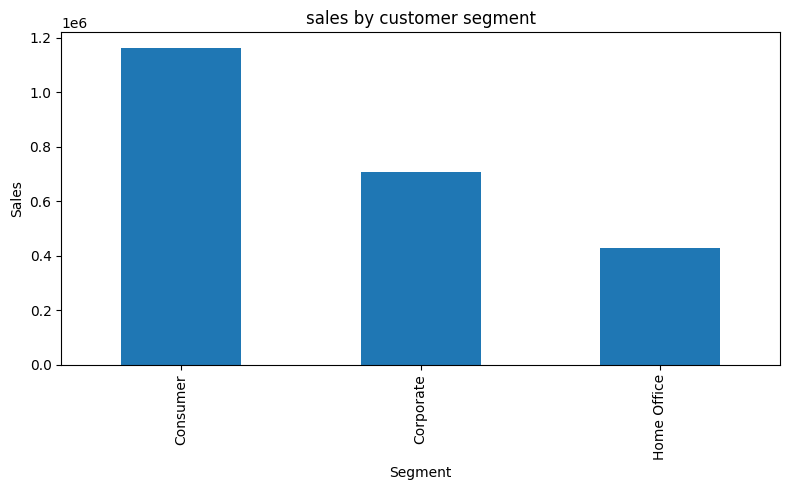

In [26]:
segment_sales.plot(kind='bar',figsize=(8,5))
plt.title('sales by customer segment')
plt.xlabel('Segment')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

In [27]:
numeric_df = df.select_dtypes(include=['number'])

correlation = numeric_df.corr()

print(correlation)

               Row ID  Postal Code     Sales  Quantity  Discount    Profit  \
Row ID       1.000000     0.009671 -0.001359 -0.004016  0.013480  0.012497   
Postal Code  0.009671     1.000000 -0.023854  0.012761  0.058443 -0.029961   
Sales       -0.001359    -0.023854  1.000000  0.200795 -0.028190  0.479064   
Quantity    -0.004016     0.012761  0.200795  1.000000  0.008623  0.066253   
Discount     0.013480     0.058443 -0.028190  0.008623  1.000000 -0.219487   
Profit       0.012497    -0.029961  0.479064  0.066253 -0.219487  1.000000   
Year         0.015430     0.004299 -0.009679 -0.005810 -0.002662  0.004670   
Month       -0.018732     0.026234 -0.000625  0.023355 -0.004935 -0.000502   
Day          0.001832     0.016840  0.003150  0.011614 -0.004016 -0.002965   

                 Year     Month       Day  
Row ID       0.015430 -0.018732  0.001832  
Postal Code  0.004299  0.026234  0.016840  
Sales       -0.009679 -0.000625  0.003150  
Quantity    -0.005810  0.023355  0.011614  

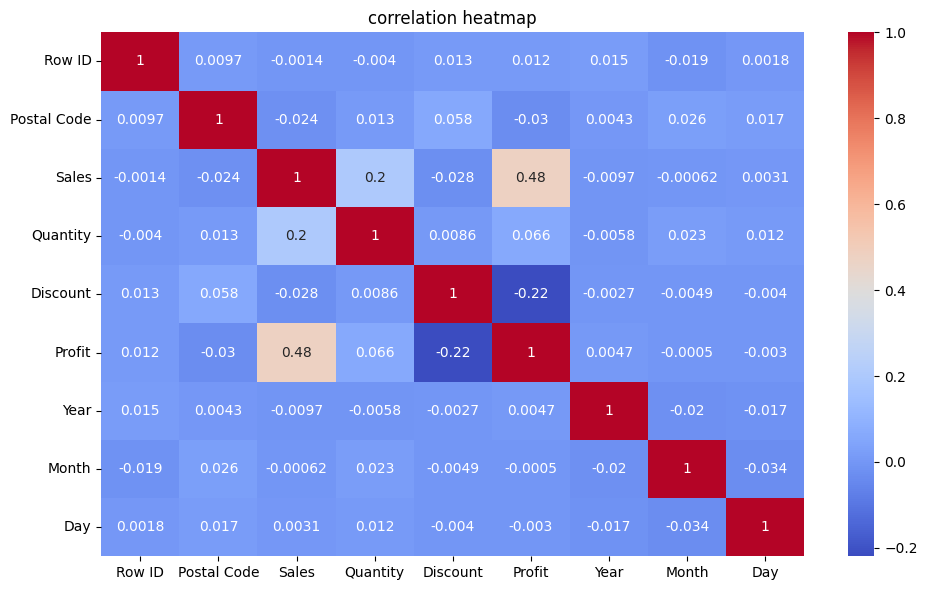

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.title("correlation heatmap")
plt.tight_layout()
plt.show()

In [29]:
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

print(subcategory_sales)

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64


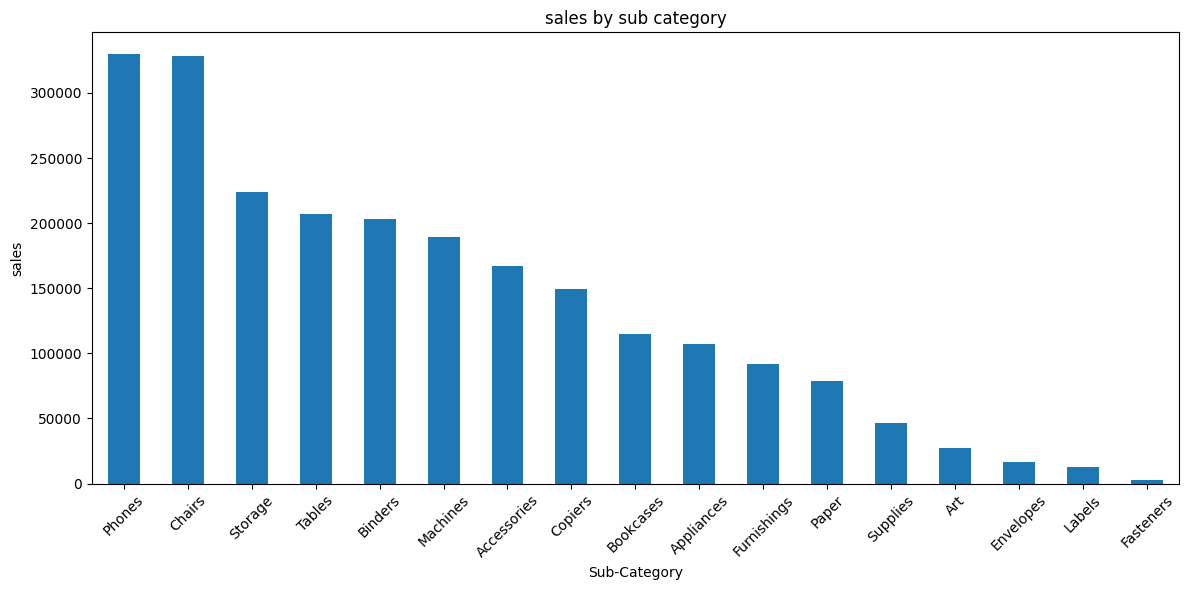

In [32]:
subcategory_sales.plot(kind='bar',figsize=(12,6))
plt.title("sales by sub category")
plt.xlabel('Sub-Category')
plt.ylabel('sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
state_sales=df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
print(state_sales)

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


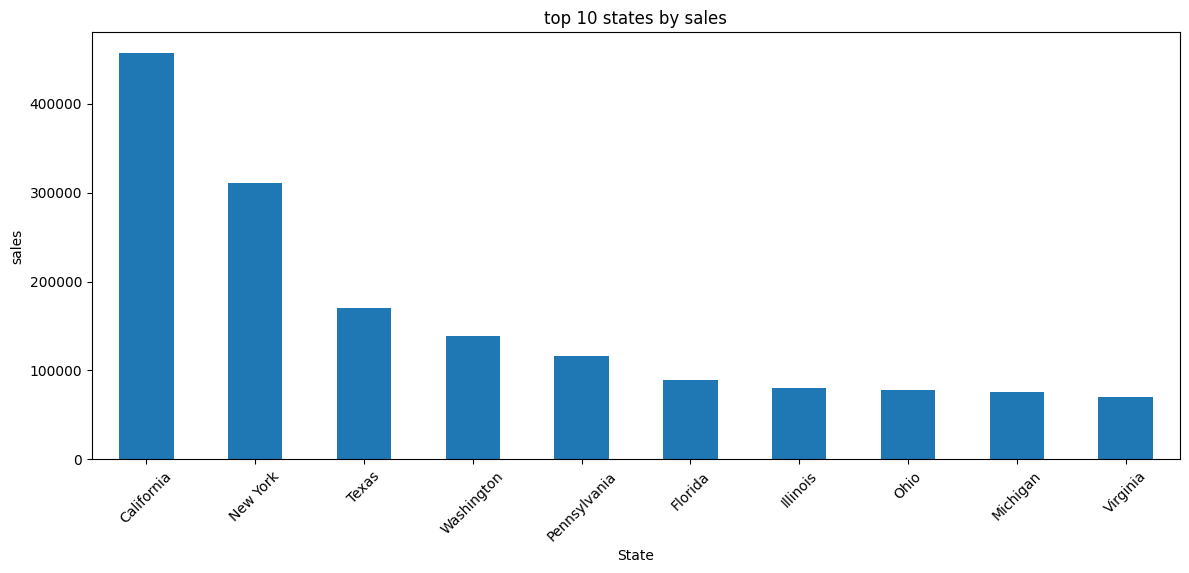

In [35]:
state_sales.plot(kind='bar',figsize=(12,6))
plt.title("top 10 states by sales")
plt.xlabel('State')
plt.ylabel('sales')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [36]:
top_customers=df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_customers)


Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


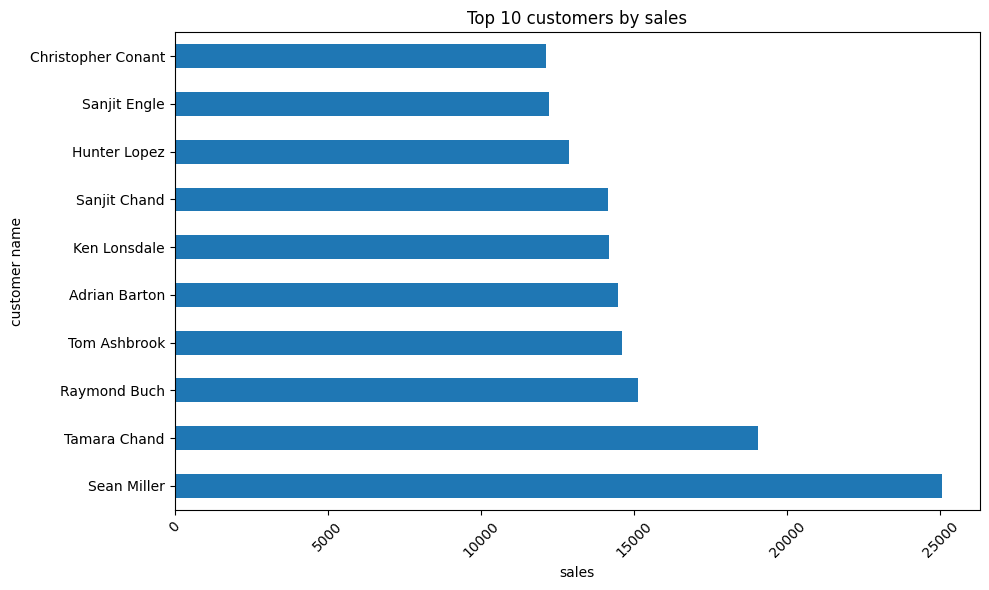

In [41]:
top_customers.plot(kind='barh',figsize=(10,6))
plt.title("Top 10 customers by sales")
plt.xlabel('sales')
plt.ylabel('customer name')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
df.to_csv('../python_files/cleaned_retail_data.csv',index=False)